# Morfología Matemática

### CC235 · Procesamiento de Imágenes

**Referencia principal:** R. C. González y R. E. Woods, *Digital Image Processing*, 3.ª edición — **Capítulo 9**.

---

Esta es la **sesión** del curso. Reunimos todo lo aprendido (imágenes como matrices, vecindades, operaciones de conjunto, filtrado espacial) y lo llevamos a una nueva familia de herramientas: la **morfología matemática**.

**¿Qué vamos a lograr hoy?**

1. Entender que una imagen binaria **es un conjunto** y que las operaciones morfológicas son operaciones de conjuntos.
2. Construir, *desde cero*, las dos operaciones fundamentales: **dilatación** y **erosión**.
3. Combinarlas para obtener **apertura**, **cierre**, **extracción de bordes** y la transformada **hit-or-miss**.
4. Aplicar todo a problemas reales: **quitar ruido**, **rellenar huecos**, **detectar patrones** y **separar objetos**.





## 0. Preparación del entorno

Cargamos las librerías. Solo necesitamos `numpy` (matrices), `matplotlib` (visualización) y `scipy.ndimage` (lo usaremos **únicamente para verificar** que nuestras implementaciones desde cero son correctas).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage  # solo para verificar nuestras funciones

SEED = 2026
rng = np.random.default_rng(SEED)

# Estilo de visualizacion consistente en todo el notebook
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


def show(images, titles=None, cmap="gray", figsize=None, suptitle=None):
    '''Muestra una o varias imagenes binarias/grises en una fila.'''
    if not isinstance(images, (list, tuple)):
        images = [images]
    n = len(images)
    if titles is None:
        titles = [""] * n
    if figsize is None:
        figsize = (3.2 * n, 3.2)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, t in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1 if img.max() <= 1 else img.max())
        ax.set_title(t, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.04)
    plt.tight_layout()
    plt.show()


def show_grid(img, title="", origin=None, figsize=(3.4, 3.4), color="#2563eb"):
    '''Dibuja una matriz pequena celda por celda, con sus valores 0/1.
    Util para ver elementos estructurantes y ejemplos a mano.'''
    M, N = img.shape
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray_r", vmin=0, vmax=1)
    for i in range(M):
        for j in range(N):
            v = int(img[i, j])
            ax.text(j, i, str(v), ha="center", va="center",
                    color="white" if v == 1 else "#9ca3af", fontsize=12, fontweight="bold")
    if origin is not None:
        oi, oj = origin
        ax.add_patch(plt.Circle((oj, oi), 0.18, color=color, zorder=5))
    ax.set_xticks(range(N)); ax.set_yticks(range(M))
    ax.set_title(title, fontsize=11)
    ax.set_xticks(np.arange(-.5, N, 1), minor=True)
    ax.set_yticks(np.arange(-.5, M, 1), minor=True)
    ax.grid(which="minor", color="#d1d5db", linewidth=1)
    ax.tick_params(which="minor", length=0)
    plt.tight_layout()
    plt.show()


print("Entorno listo. SEED =", SEED)


Entorno listo. SEED = 2026


## 1. ¿Qué es la morfología matemática?

La palabra **morfología** viene de la biología: el estudio de la **forma y la estructura** de los seres vivos. La **morfología matemática** traslada esa idea a las imágenes: es un conjunto de herramientas para **extraer componentes** que describen la forma de las regiones (bordes, esqueletos, envolventes convexas, etc.).

**Un poco de historia.** La teoría nació en los años 60, desarrollada por **Georges Matheron** y **Jean Serra** en la Escuela de Minas de París. Se diseñó primero para **imágenes binarias** y luego se extendió a escala de grises.

**¿Dónde se usa?** Medicina, biología, metalurgia, microscopía, análisis de texturas y automatización industrial. Tareas típicas:

- Extracción de componentes conexos y bordes.
- Búsqueda de patrones específicos.
- Limpieza de ruido y relleno de huecos.
- Afinamiento (esqueletos) y envolvente convexa.

**La idea clave de hoy.** Trabajaremos con **imágenes binarias**: cada píxel es 1 (objeto, primer plano) o 0 (fondo). El truco mental es:

> Una imagen binaria **es un conjunto**: el conjunto de las coordenadas donde hay un 1.

Si una imagen es un conjunto, entonces podemos aplicarle operaciones de conjuntos (unión, intersección, complemento, traslación...). **La morfología es exactamente eso.**


## 2. Una imagen binaria es un conjunto

Empecemos por lo más concreto. Tomemos una matriz pequeña de 0 y 1 y veámosla de las **dos formas equivalentes**: como matriz y como conjunto de coordenadas $(fila, columna)$.

El conjunto de un objeto $A$ se define como:

$$A = \{\, (i, j) \;\mid\; \text{imagen}[i, j] = 1 \,\}$$


In [2]:
# Una imagen binaria 5x6 (5 filas, 6 columnas)
A_img = np.array([
    [0, 1, 0, 1, 0, 0],
    [1, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1],
], dtype=np.uint8)


def image_to_set(img):
    '''Convierte una imagen binaria en un conjunto de coordenadas (fila, col).'''
    return {(int(i), int(j)) for i, j in np.argwhere(img == 1)}


def set_to_image(coords, shape):
    '''Reconstruye la imagen binaria a partir de un conjunto de coordenadas.'''
    out = np.zeros(shape, dtype=np.uint8)
    for (i, j) in coords:
        if 0 <= i < shape[0] and 0 <= j < shape[1]:
            out[i, j] = 1
    return out


A_set = image_to_set(A_img)
print("Conjunto A (fila, col):")
print(sorted(A_set))

# Verificacion: ida y vuelta debe devolver la misma imagen
assert np.array_equal(set_to_image(A_set, A_img.shape), A_img)
print("\n[VERIFICACION] imagen -> conjunto -> imagen: OK")


Conjunto A (fila, col):
[(0, 1), (0, 3), (1, 0), (1, 2), (2, 1), (2, 4), (4, 5)]

[VERIFICACION] imagen -> conjunto -> imagen: OK


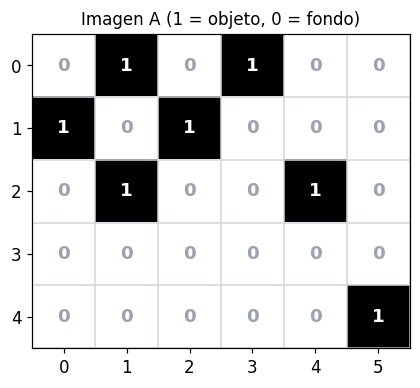

In [3]:
show_grid(A_img, "Imagen A (1 = objeto, 0 = fondo)", figsize=(4.2, 3.6))

**Operaciones de conjuntos = operaciones lógicas sobre la matriz.** Como una imagen binaria es un conjunto, las operaciones básicas tienen una traducción directa a NumPy:

| Conjuntos | Significado | NumPy |
|---|---|---|
| $A \cup B$ | unión | `A | B` |
| $A \cap B$ | intersección | `A & B` |
| $A^{c}$ | complemento | `1 - A` |
| $A - B$ | diferencia | `A & (1 - B)` |


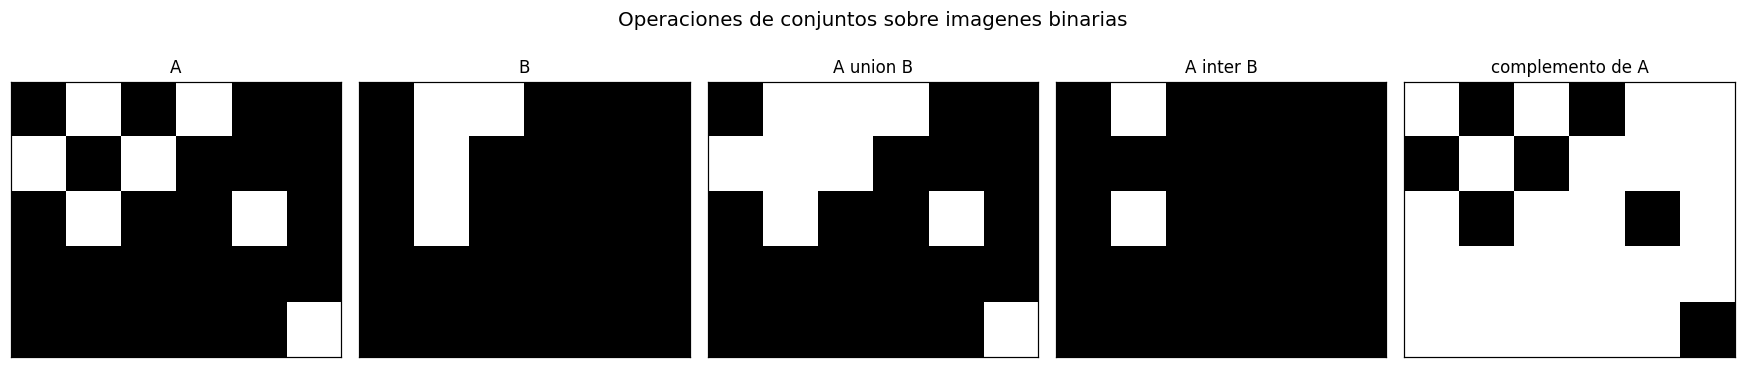

In [4]:
B_img = np.array([
    [0, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0],
], dtype=np.uint8)

union = A_img | B_img
inter = A_img & B_img
comp_A = 1 - A_img
diff = A_img & (1 - B_img)

show([A_img, B_img, union, inter, comp_A],
     ["A", "B", "A union B", "A inter B", "complemento de A"],
     suptitle="Operaciones de conjuntos sobre imagenes binarias")


## 3. Dos movimientos fundamentales: traslación y reflexión

La morfología se construye moviendo conjuntos. Hay dos movimientos básicos.

**Traslación.** Mover el conjunto $A$ por un vector $p = (z_1, z_2)$:

$$(A)_p = \{\, a + p \;\mid\; a \in A \,\}$$

Es decir, sumamos el mismo desplazamiento a cada punto.

**Reflexión.** Voltear el conjunto respecto a su origen:

$$\hat{A} = \{\, -a \;\mid\; a \in A \,\}$$

La reflexión será clave para entender por qué la erosión y la dilatación son "duales".


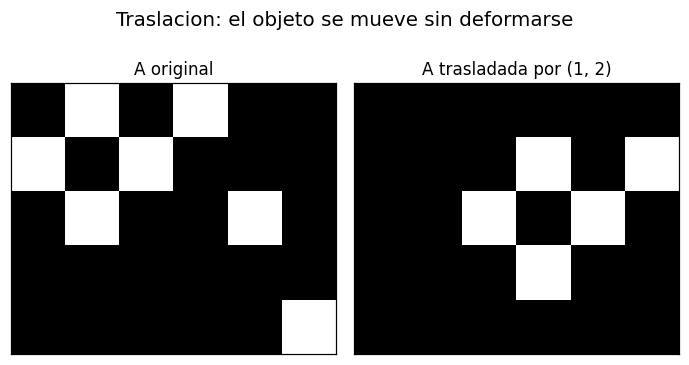

In [5]:
def translate_set(coords, p):
    '''Traslada un conjunto de coordenadas por el vector p = (dr, dc).'''
    dr, dc = p
    return {(i + dr, j + dc) for (i, j) in coords}


def reflect_set(coords):
    '''Refleja un conjunto respecto al origen (0, 0).'''
    return {(-i, -j) for (i, j) in coords}


# Demostracion sobre la imagen A
A_trans = set_to_image(translate_set(A_set, (1, 2)), A_img.shape)  # baja 1, derecha 2

show([A_img, A_trans], ["A original", "A trasladada por (1, 2)"],
     suptitle="Traslacion: el objeto se mueve sin deformarse")


La **reflexión** se ve mejor con un elemento centrado en el origen. Construimos un pequeño objeto asimétrico alrededor de $(0,0)$ y lo reflejamos.

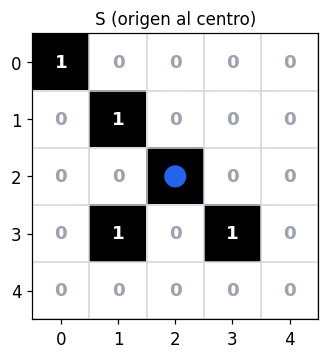

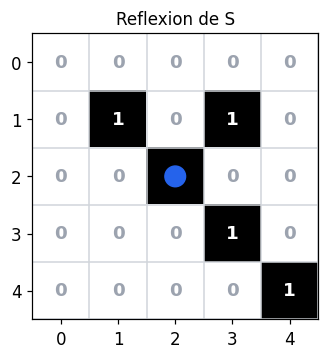

S    : [(-2, -2), (-1, -1), (0, 0), (1, -1), (1, 1)]
S_ref: [(-1, -1), (-1, 1), (0, 0), (1, 1), (2, 2)]


In [6]:
# Objeto pequeno definido con coordenadas que pueden ser negativas
S = {(-2, -2), (-1, -1), (0, 0), (1, 1), (1, -1)}
S_ref = reflect_set(S)

# Para dibujarlos, los centramos en una rejilla 5x5 (origen en el centro = (2,2))
def center_on_grid(coords, half=2):
    img = np.zeros((2 * half + 1, 2 * half + 1), dtype=np.uint8)
    for (i, j) in coords:
        img[i + half, j + half] = 1
    return img

show_grid(center_on_grid(S), "S (origen al centro)", origin=(2, 2))
show_grid(center_on_grid(S_ref), "Reflexion de S", origin=(2, 2))
print("S    :", sorted(S))
print("S_ref:", sorted(S_ref))


## 4. El elemento estructurante (SE)

Toda operación morfológica usa una pequeña "sonda" llamada **elemento estructurante** (*structuring element*, SE). Es una imagen binaria diminuta —típicamente $3\times 3$ o un disco pequeño— **con un origen marcado** (normalmente su centro).

El SE se desplaza por toda la imagen y, en cada posición, **decide** si el píxel de salida es 0 o 1. La **forma** y el **tamaño** del SE determinan completamente el efecto. Cambiar el SE cambia el resultado.

Definimos los elementos estructurantes más usados.


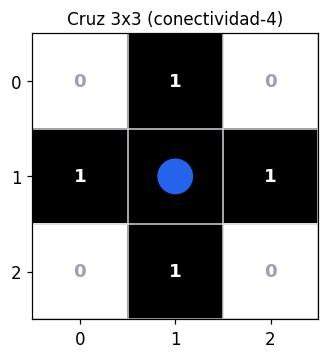

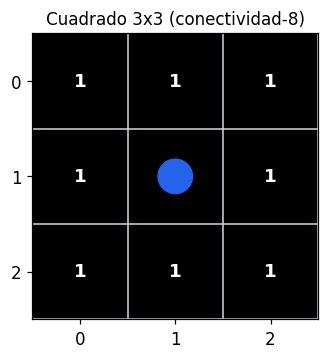

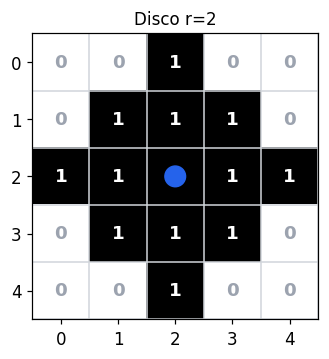

In [7]:
def se_cross(r=1):
    '''Cruz (conectividad-4): centro + brazos horizontales y verticales.'''
    size = 2 * r + 1
    s = np.zeros((size, size), dtype=np.uint8)
    s[r, :] = 1
    s[:, r] = 1
    return s, (r, r)


def se_square(r=1):
    '''Cuadrado lleno (conectividad-8).'''
    size = 2 * r + 1
    return np.ones((size, size), dtype=np.uint8), (r, r)


def se_disk(r=2):
    '''Disco de radio r.'''
    size = 2 * r + 1
    yy, xx = np.ogrid[-r:r + 1, -r:r + 1]
    s = (xx**2 + yy**2 <= r**2).astype(np.uint8)
    return s, (r, r)


def se_line_h(length=3):
    '''Linea horizontal.'''
    s = np.ones((1, length), dtype=np.uint8)
    return s, (0, length // 2)


cross, oc = se_cross(1)
square, osq = se_square(1)
disk, od = se_disk(2)

show_grid(cross, "Cruz 3x3 (conectividad-4)", origin=oc)
show_grid(square, "Cuadrado 3x3 (conectividad-8)", origin=osq)
show_grid(disk, "Disco r=2", origin=od)


> **Intuición:** la cruz toca solo a los 4 vecinos directos; el cuadrado toca a los 8 vecinos. El disco produce resultados más "redondos" e isotrópicos. La línea actúa solo en una dirección (útil para detectar o eliminar estructuras orientadas).

## 5. Dilatación — *engordar* el objeto

La **dilatación** expande las regiones de 1. Sirve para **hacer crecer** objetos, **rellenar huecos y grietas** pequeñas y **unir** partes cercanas.

**Definición (adición de Minkowski).** Dada la imagen $A$ y el SE $B$:

$$A \oplus B = \bigcup_{b \in B} (A)_b$$

En palabras: *coloca una copia del objeto desplazada por cada punto del SE y únelas todas*. Equivalentemente, recorriendo cada píxel de salida:

$$A \oplus B = \{\, p \;\mid\; (\hat{B})_p \cap A \neq \varnothing \,\}$$

*"El píxel de salida es 1 si el SE, centrado ahí, toca al menos un 1 del objeto."*

**Lo implementamos desde cero** con la visión más intuitiva: por cada píxel encendido de $A$, "estampamos" el SE.


In [8]:
def dilate(A, B, origin):
    '''Dilatacion binaria desde cero.
    A: imagen binaria (0/1). B: elemento estructurante (0/1). origin: (fila, col) en B.
    Idea: por cada pixel 1 de A, se estampa el SE.'''
    A = A.astype(np.uint8)
    M, N = A.shape
    bm, bn = B.shape
    orow, ocol = origin
    out = np.zeros_like(A)

    foreground = np.argwhere(A == 1)
    se_offsets = [(i - orow, j - ocol) for i in range(bm) for j in range(bn) if B[i, j] == 1]

    for (r, c) in foreground:
        for (dr, dc) in se_offsets:
            rr, cc = r + dr, c + dc
            if 0 <= rr < M and 0 <= cc < N:
                out[rr, cc] = 1
    return out


### Verificación 1: el ejemplo del libro (adición de Minkowski)

El libro propone: con $A = \{(1,1),(1,2),(1,3),(2,3),(2,4),(3,4)\}$ y $B = \{(0,0),(1,0)\}$, calcular $A \oplus B$. La respuesta correcta es:

$$A \oplus B = \{(1,1),(1,2),(1,3),(2,1),(2,2),(2,3),(2,4),(3,3),(3,4),(4,4)\}$$

Reproducimos ese caso exacto con nuestra función.


In [9]:
A_book = {(1, 1), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4)}
B_book = {(0, 0), (1, 0)}

# Convertimos a imagenes para usar dilate(). El SE B tiene origen en (0,0).
A_book_img = set_to_image(A_book, (6, 6))
B_book_img = np.array([[1], [1]], dtype=np.uint8)  # puntos (0,0) y (1,0): columna de 2

res_img = dilate(A_book_img, B_book_img, origin=(0, 0))
res_set = image_to_set(res_img)

expected = {(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)}
print("Resultado:", sorted(res_set))
print("Esperado :", sorted(expected))
assert res_set == expected, "El resultado no coincide con el libro"
print("\n[VERIFICACION] Adicion de Minkowski coincide con el libro (alternativa D): OK")


Resultado: [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]
Esperado : [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]

[VERIFICACION] Adicion de Minkowski coincide con el libro (alternativa D): OK


### Verificación 2: contra `scipy`

Para una imagen real, comparamos nuestra `dilate` con `scipy.ndimage.binary_dilation`. Deben dar lo mismo (usamos un SE simétrico para evitar diferencias por convención de reflexión).


[VERIFICACION] dilate() coincide con scipy.binary_dilation: OK


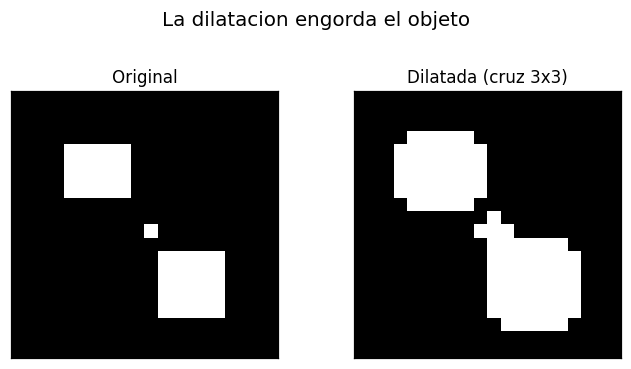

In [10]:
# Imagen de prueba con un par de formas
test = np.zeros((20, 20), dtype=np.uint8)
test[4:8, 4:9] = 1
test[12:17, 11:16] = 1
test[10, 10] = 1

se, o = se_cross(1)

mine = dilate(test, se, o)
ref = ndimage.binary_dilation(test, structure=se).astype(np.uint8)

assert np.array_equal(mine, ref), "Difiere de scipy"
print("[VERIFICACION] dilate() coincide con scipy.binary_dilation: OK")

show([test, mine], ["Original", "Dilatada (cruz 3x3)"],
     suptitle="La dilatacion engorda el objeto")


**El efecto del tamaño del SE.** Cuanto más grande es el SE, más crece el objeto.

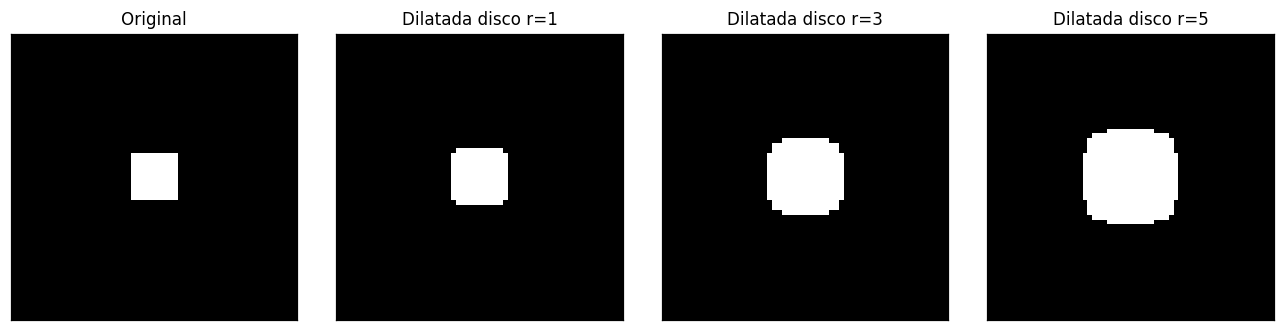

In [11]:
shape = np.zeros((60, 60), dtype=np.uint8)
shape[25:35, 25:35] = 1

variants = [shape]
titles = ["Original"]
for r in (1, 3, 5):
    d, od = se_disk(r)
    variants.append(dilate(shape, d, od))
    titles.append(f"Dilatada disco r={r}")

show(variants, titles, figsize=(12, 3))


## 6. Erosión — *adelgazar* el objeto

La **erosión** es la operación dual: **encoge** las regiones de 1. Sirve para **eliminar detalles pequeños**, **romper puentes finos** entre objetos y **eliminar ruido** de primer plano.

**Definición.** Dada $A$ y el SE $B$:

$$A \ominus B = \{\, p \;\mid\; (B)_p \subseteq A \,\}$$

*"El píxel de salida es 1 solo si el SE, colocado ahí, cabe completamente dentro del objeto."* Basta que un solo punto del SE caiga sobre fondo para que el píxel de salida sea 0.

**Implementación desde cero.**


In [12]:
def erode(A, B, origin):
    '''Erosion binaria desde cero.
    El pixel de salida es 1 solo si el SE cabe ENTERO dentro de A.'''
    A = A.astype(np.uint8)
    M, N = A.shape
    bm, bn = B.shape
    orow, ocol = origin
    out = np.zeros_like(A)

    se_offsets = [(i - orow, j - ocol) for i in range(bm) for j in range(bn) if B[i, j] == 1]

    for r in range(M):
        for c in range(N):
            fits = True
            for (dr, dc) in se_offsets:
                rr, cc = r + dr, c + dc
                # fuera de la imagen = fondo (0): el SE no cabe
                if not (0 <= rr < M and 0 <= cc < N and A[rr, cc] == 1):
                    fits = False
                    break
            out[r, c] = 1 if fits else 0
    return out


[VERIFICACION] erode() coincide con scipy.binary_erosion: OK


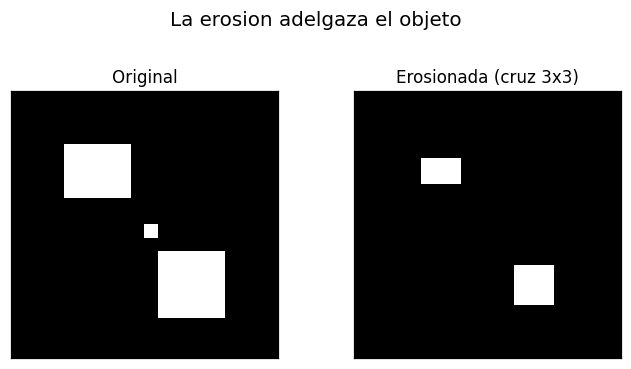

In [13]:
# Verificacion contra scipy
se, o = se_cross(1)
mine = erode(test, se, o)
ref = ndimage.binary_erosion(test, structure=se).astype(np.uint8)
assert np.array_equal(mine, ref), "Difiere de scipy"
print("[VERIFICACION] erode() coincide con scipy.binary_erosion: OK")

show([test, mine], ["Original", "Erosionada (cruz 3x3)"],
     suptitle="La erosion adelgaza el objeto")


### Dualidad erosión–dilatación

Erosión y dilatación son **operaciones duales** respecto al complemento y la reflexión:

$$A \ominus B = \left( A^{c} \oplus \hat{B} \right)^{c}$$

Es decir: *erosionar el objeto equivale a dilatar el fondo*. Lo comprobamos numéricamente.


In [14]:
se, o = se_square(1)  # SE simetrico: B = B_reflejado
B_ref = se[::-1, ::-1]
origin_ref = (se.shape[0] - 1 - o[0], se.shape[1] - 1 - o[1])

left = erode(test, se, o)
right = 1 - dilate(1 - test, B_ref, origin_ref)

assert np.array_equal(left, right), "La dualidad no se cumple"
print("[VERIFICACION] A erosion B == complemento( complemento(A) dilatado por B_reflejado ): OK")


[VERIFICACION] A erosion B == complemento( complemento(A) dilatado por B_reflejado ): OK


## 7. Apertura y cierre — limpieza inteligente

Erosión y dilatación por separado cambian el tamaño del objeto. Si las **combinamos**, obtenemos dos operaciones que **limpian sin encoger ni engordar de forma neta**.

**Apertura** (*opening*): erosión seguida de dilatación.

$$A \circ B = (A \ominus B) \oplus B$$

Elimina **salientes finos, ruido y objetos más pequeños que el SE**, conservando el tamaño general de lo que sobrevive. Suaviza contornos por fuera.

**Cierre** (*closing*): dilatación seguida de erosión.

$$A \bullet B = (A \oplus B) \ominus B$$

**Rellena huecos pequeños, grietas y entrantes** sin agrandar el objeto. Suaviza contornos por dentro.

> Regla mnemotécnica: la **apertura abre** los espacios entre objetos (quita lo blanco pequeño); el **cierre cierra** los agujeros (rellena lo negro pequeño).


In [15]:
def opening(A, B, origin):
    '''Apertura: erosion seguida de dilatacion.'''
    return dilate(erode(A, B, origin), B, origin)


def closing(A, B, origin):
    '''Cierre: dilatacion seguida de erosion.'''
    return erode(dilate(A, B, origin), B, origin)


### Caso aplicado: quitar ruido sal y pimienta

Generamos un objeto limpio, le agregamos **ruido**: puntos blancos sueltos en el fondo (sal) y agujeros negros dentro del objeto (pimienta). Veremos cómo la **apertura** elimina la sal y el **cierre** elimina la pimienta.


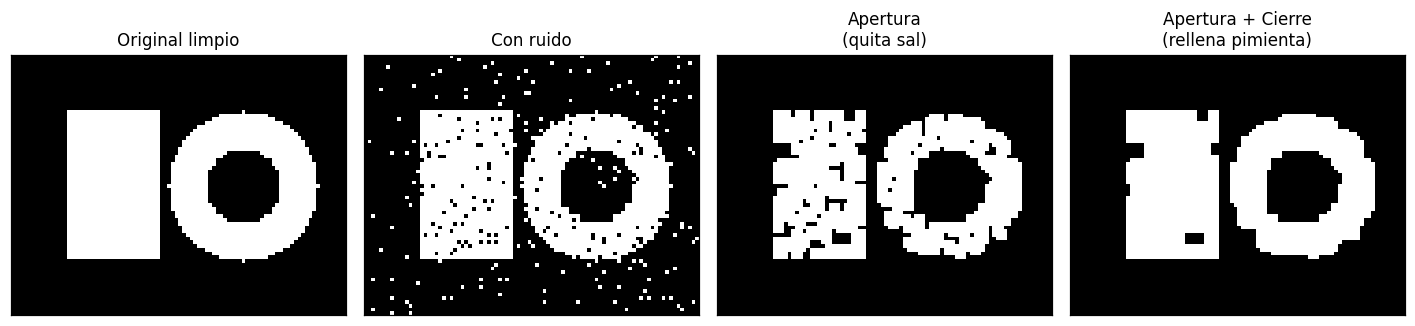

In [16]:
# Objeto limpio: un anillo + un rectangulo
clean = np.zeros((70, 90), dtype=np.uint8)
clean[15:55, 15:40] = 1                       # rectangulo
yy, xx = np.ogrid[:70, :90]
ring = ((xx - 62)**2 + (yy - 35)**2 <= 20**2) & ((xx - 62)**2 + (yy - 35)**2 >= 10**2)
clean[ring] = 1

# Anadir ruido reproducible
noisy = clean.copy()
salt = rng.random(clean.shape) < 0.04      # puntos blancos en el fondo
pepper = rng.random(clean.shape) < 0.06    # agujeros negros en el objeto
noisy[salt & (clean == 0)] = 1
noisy[pepper & (clean == 1)] = 0

se, o = se_square(1)
opened = opening(noisy, se, o)             # quita la sal
restored = closing(opened, se, o)          # rellena la pimienta

show([clean, noisy, opened, restored],
     ["Original limpio", "Con ruido", "Apertura\n(quita sal)", "Apertura + Cierre\n(rellena pimienta)"],
     figsize=(13, 3.4))


In [17]:
# Cuanto se parece el resultado al original limpio?
def iou(X, Y):
    inter = np.logical_and(X, Y).sum()
    union = np.logical_or(X, Y).sum()
    return inter / union if union else 1.0

print(f"IoU ruidoso vs limpio    : {iou(noisy, clean):.3f}")
print(f"IoU restaurado vs limpio : {iou(restored, clean):.3f}")
print("\n[VERIFICACION] El IoU mejora tras apertura+cierre:",
      "OK" if iou(restored, clean) > iou(noisy, clean) else "REVISAR")


IoU ruidoso vs limpio    : 0.876
IoU restaurado vs limpio : 0.933

[VERIFICACION] El IoU mejora tras apertura+cierre: OK


## 8. Extracción de bordes

Una combinación muy elegante: el **borde** de un objeto es lo que queda al restarle su versión erosionada.

$$\partial A = A - (A \ominus B)$$

La erosión "come" una capa del borde; al restarla del original, **queda solo el contorno**. El grosor del borde depende del SE.


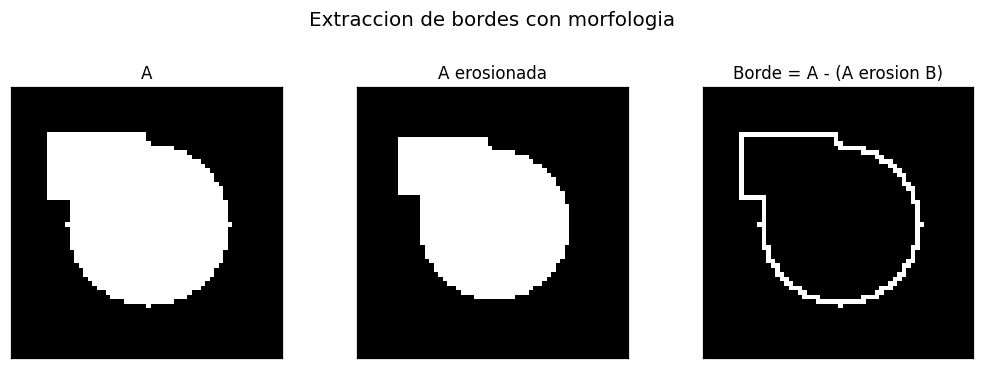

In [18]:
def boundary(A, B, origin):
    '''Extraccion de borde: A menos su erosion.'''
    eroded = erode(A, B, origin)
    return (A & (1 - eroded)).astype(np.uint8)


# Un objeto solido
blob = np.zeros((60, 60), dtype=np.uint8)
yy, xx = np.ogrid[:60, :60]
blob[(xx - 30)**2 + (yy - 30)**2 <= 18**2] = 1
blob[10:25, 8:30] = 1

se, o = se_square(1)
edge = boundary(blob, se, o)

show([blob, erode(blob, se, o), edge],
     ["A", "A erosionada", "Borde = A - (A erosion B)"],
     suptitle="Extraccion de bordes con morfologia")


## 9. Transformada Hit-or-Miss — detectar patrones exactos

Hasta ahora preguntábamos "¿el SE cabe?". La **transformada hit-or-miss** va más allá: busca una **configuración exacta** de primer plano *y* de fondo. Es la base para detectar **patrones específicos**: esquinas, puntos aislados, extremos de línea, etc.

El elemento estructurante ahora tiene **tres valores posibles** en cada posición:

- `1` → ahí **debe haber** primer plano.
- `0` → ahí **debe haber** fondo.
- "no importa" → cualquier valor sirve (lo marcamos como `-1`).

Formalmente, usando dos SE complementarios $B_1$ (lo que debe ser objeto) y $B_2$ (lo que debe ser fondo):

$$A \circledast B = (A \ominus B_1) \,\cap\, (A^{c} \ominus B_2)$$

El píxel de salida es 1 **solo** donde el patrón coincide **exactamente**.


In [19]:
def hit_or_miss(A, SE, origin):
    '''Transformada hit-or-miss.
    SE usa: 1 = debe ser objeto, 0 = debe ser fondo, -1 = no importa.'''
    A = A.astype(np.uint8)
    M, N = A.shape
    bm, bn = SE.shape
    orow, ocol = origin
    out = np.zeros_like(A)

    constraints = [(i - orow, j - ocol, SE[i, j])
                   for i in range(bm) for j in range(bn) if SE[i, j] != -1]

    for r in range(M):
        for c in range(N):
            match = True
            for (dr, dc, want) in constraints:
                rr, cc = r + dr, c + dc
                val = A[rr, cc] if (0 <= rr < M and 0 <= cc < N) else 0  # fuera = fondo
                if val != want:
                    match = False
                    break
            out[r, c] = 1 if match else 0
    return out


### Verificación con el caso del libro

El libro plantea: dado el patrón de entrada y el elemento estructurante de abajo, ¿la transformada da *True* (hay coincidencia) en el centro?

```
Imagen de entrada       Elemento estructurante
0 0 0                   0 0 0
1 1 0                   -- 1 --     (-- = no importa)
1 1 1                   1 1 1
```

Revisemos posición por posición, colocando el origen del SE en el centro:

- Fila superior del SE: exige **fondo** `0 0 0` → la entrada tiene `0 0 0`. Coincide.
- Fila central: solo exige que el **centro** sea objeto (`1`); los lados son "no importa". El centro de la entrada es `1`. Coincide.
- Fila inferior del SE: exige **objeto** `1 1 1` → la entrada tiene `1 1 1`. Coincide.

Como **todas** las posiciones exigidas coinciden, la respuesta es **True**. Lo comprobamos.


In [20]:
entrada = np.array([
    [0, 0, 0],
    [1, 1, 0],
    [1, 1, 1],
], dtype=np.uint8)

# SE: 0 = fondo, 1 = objeto, -1 = no importa
SE_hm = np.array([
    [ 0,  0,  0],
    [-1,  1, -1],
    [ 1,  1,  1],
], dtype=int)

resultado = hit_or_miss(entrada, SE_hm, origin=(1, 1))
centro = resultado[1, 1]
print("Valor de la transformada en el centro:", bool(centro))
assert centro == 1, "Deberia ser True"
print("\n[VERIFICACION] Caso del libro -> True (el patron coincide): OK")


Valor de la transformada en el centro: True

[VERIFICACION] Caso del libro -> True (el patron coincide): OK


### Aplicación: detectar puntos aislados y esquinas

Diseñamos un SE que detecta **un punto aislado**: objeto en el centro rodeado completamente de fondo. Y otro que detecta **esquinas superiores izquierdas**.


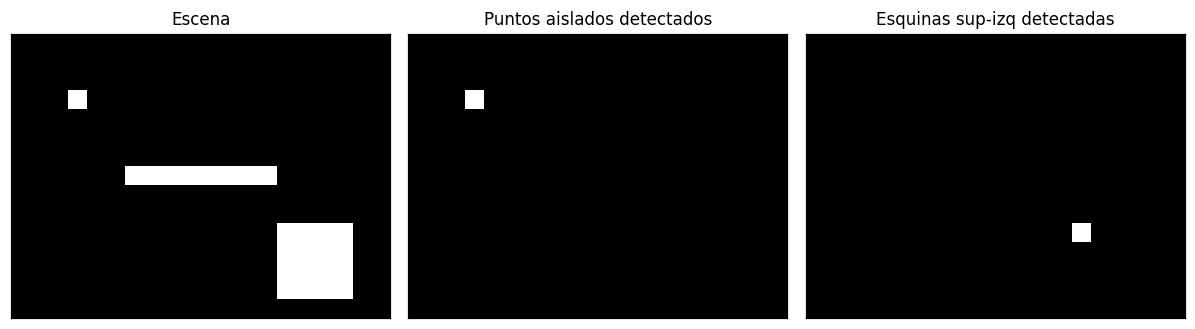

Puntos aislados encontrados: 1


In [21]:
# Imagen con un punto aislado, una linea y un bloque
scene = np.zeros((15, 20), dtype=np.uint8)
scene[3, 3] = 1                  # punto aislado
scene[7, 6:14] = 1               # linea horizontal
scene[10:14, 14:18] = 1          # bloque solido

# SE para PUNTO AISLADO: centro objeto, todo el resto fondo
SE_isolated = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0],
], dtype=int)
puntos = hit_or_miss(scene, SE_isolated, origin=(1, 1))

# SE para ESQUINA superior-izquierda de un bloque:
# fondo arriba y a la izquierda, objeto en el centro y hacia abajo-derecha
SE_corner = np.array([
    [ 0,  0, -1],
    [ 0,  1,  1],
    [-1,  1, -1],
], dtype=int)
esquinas = hit_or_miss(scene, SE_corner, origin=(1, 1))

show([scene, puntos, esquinas],
     ["Escena", "Puntos aislados detectados", "Esquinas sup-izq detectadas"],
     figsize=(11, 3))
print("Puntos aislados encontrados:", int(puntos.sum()))


## 10. Caso integrador: contar y separar granos

Cerramos con un mini-pipeline realista, parecido a un problema de **microscopía / control de calidad industrial**: tenemos una imagen binaria de "granos" (o células) donde algunos se **tocan** y hay **ruido**. Queremos limpiar la imagen, **separar** los objetos pegados y **contarlos**.

Estrategia:
1. **Apertura** para quitar el ruido pequeño.
2. **Erosión** fuerte para separar objetos que se tocan por puentes finos.
3. **Etiquetado de componentes conexos** para contar (usamos `scipy.ndimage.label`, que ya conocemos como herramienta de conteo).


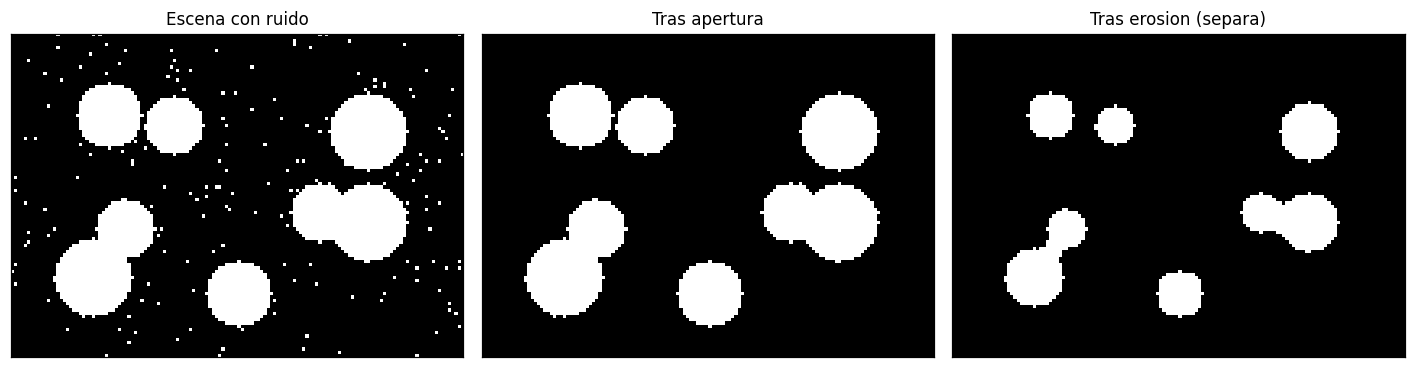

Objetos contados solo con limpieza : 6
Objetos contados tras separar      : 6
Granos reales colocados            : 8


In [22]:
# Generar una escena de granos sinteticos reproducible
scene = np.zeros((100, 140), dtype=np.uint8)
centers = [(25, 30), (28, 50), (60, 35), (55, 95), (58, 110),
           (80, 70), (30, 110), (75, 25)]
yy, xx = np.ogrid[:100, :140]
for (cy, cx) in centers:
    rr = rng.integers(9, 13)
    scene[(xx - cx)**2 + (yy - cy)**2 <= rr**2] = 1

# Ruido: motas pequenas en el fondo
mota = rng.random(scene.shape) < 0.015
scene[mota] = 1

se, o = se_disk(2)
step1 = opening(scene, se, o)              # quita el ruido
se2, o2 = se_disk(3)
step2 = erode(step1, se2, o2)              # separa los que se tocan

labels, n_clean = ndimage.label(step1)
labels_sep, n_sep = ndimage.label(step2)

show([scene, step1, step2],
     ["Escena con ruido", "Tras apertura", "Tras erosion (separa)"],
     figsize=(13, 3.4))
print(f"Objetos contados solo con limpieza : {n_clean}")
print(f"Objetos contados tras separar      : {n_sep}")
print(f"Granos reales colocados            : {len(centers)}")


## 11. Resumen visual

| Operación | Definición | Para qué sirve |
|---|---|---|
| **Dilatación** $A \oplus B$ | une copias trasladadas | engordar, rellenar, unir |
| **Erosión** $A \ominus B$ | el SE debe caber entero | adelgazar, separar, limpiar |
| **Apertura** $A \circ B$ | $(A \ominus B) \oplus B$ | quitar ruido y salientes finos |
| **Cierre** $A \bullet B$ | $(A \oplus B) \ominus B$ | rellenar huecos y grietas |
| **Borde** | $A - (A \ominus B)$ | extraer contornos |
| **Hit-or-Miss** | $(A \ominus B_1) \cap (A^c \ominus B_2)$ | detectar patrones exactos |

**Ideas para llevarse:**

- Una imagen binaria es un **conjunto**; la morfología son **operaciones de conjuntos**.
- Todo se construye a partir de **dilatación** y **erosión**, que son **duales**.
- El **elemento estructurante** (forma, tamaño, origen) decide el resultado.
- Combinando operaciones limpiamos, medimos y describimos formas sin redes neuronales: pura geometría.


## 12. Ejercicios calificados

Completa las tres funciones. Cada una tiene una celda de **verificación automática** justo debajo. Reemplaza el bloque marcado con `# TODO` por tu solución. Las funciones que ya implementamos (`dilate`, `erode`, `opening`, `closing`, `boundary`, `hit_or_miss`) están disponibles y puedes usarlas.

> Mientras no completes un ejercicio, su placeholder devuelve un valor válido (para que el notebook corra) pero la verificación marcará `[!] PENDIENTE`.


### Ejercicio 1 — Gradiente morfológico

El **gradiente morfológico** resalta los bordes de forma más simétrica que la resta simple. Se define como la **dilatación menos la erosión**:

$$g = (A \oplus B) - (A \ominus B)$$

Implementa `morphological_gradient`.


In [23]:
def morphological_gradient(A, B, origin):
    '''Gradiente morfologico: dilatacion menos erosion.'''
    # TODO: reemplaza esta linea por tu solucion
    print("[!] morphological_gradient sin implementar: devuelve placeholder")
    return np.zeros_like(A)
    # Pista: usa dilate(...) y erode(...) y combina con operaciones de conjunto.


In [24]:
# VERIFICACION - Ejercicio 1
se, o = se_square(1)
g = morphological_gradient(blob, se, o)
ref_g = (dilate(blob, se, o) & (1 - erode(blob, se, o))).astype(np.uint8)
if np.array_equal(g, ref_g) and g.sum() > 0:
    print("[OK] Ejercicio 1 correcto. Pixeles de borde:", int(g.sum()))
    show([blob, g], ["A", "Gradiente morfologico"])
else:
    print("[!] PENDIENTE: el gradiente aun no coincide con el esperado.")


[!] morphological_gradient sin implementar: devuelve placeholder
[!] PENDIENTE: el gradiente aun no coincide con el esperado.


### Ejercicio 2 — Top-hat (sombrero de copa)

La transformada **top-hat** revela detalles claros más pequeños que el SE y corrige iluminación desigual. Se define como el **original menos su apertura**:

$$\text{tophat}(A) = A - (A \circ B)$$

Implementa `top_hat`.


In [25]:
def top_hat(A, B, origin):
    '''Top-hat: original menos su apertura.'''
    # TODO: reemplaza esta linea por tu solucion
    print("[!] top_hat sin implementar: devuelve placeholder")
    return np.zeros_like(A)


In [26]:
# VERIFICACION - Ejercicio 2
# Imagen: bloque grande + detalles pequenos
img2 = np.zeros((50, 70), dtype=np.uint8)
img2[10:40, 10:45] = 1          # bloque grande
img2[5, 55] = 1                 # detalle pequeno 1
img2[20, 60:63] = 1             # detalle pequeno 2

se, o = se_square(2)
th = top_hat(img2, se, o)
ref_th = (img2 & (1 - opening(img2, se, o))).astype(np.uint8)
if np.array_equal(th, ref_th) and th.sum() > 0:
    print("[OK] Ejercicio 2 correcto.")
    show([img2, opening(img2, se, o), th], ["A", "Apertura", "Top-hat (detalles)"])
else:
    print("[!] PENDIENTE: el top-hat aun no coincide con el esperado.")


[!] top_hat sin implementar: devuelve placeholder
[!] PENDIENTE: el top-hat aun no coincide con el esperado.


### Ejercicio 3 — Detector de extremos de línea

Diseña un elemento estructurante para `hit_or_miss` que detecte el **extremo derecho** de una línea horizontal: un píxel de objeto cuyo vecino izquierdo es objeto y cuyos vecinos derecho, superior e inferior son fondo.

Define el SE `SE_endpoint` (matriz $3\times3$ con valores `1`, `0`, `-1`) y su origen.


In [27]:
# TODO: completa el SE para detectar el extremo derecho de una linea horizontal.
# 1 = debe ser objeto, 0 = debe ser fondo, -1 = no importa.
# Placeholder (no detecta nada util todavia):
SE_endpoint = np.array([
    [-1, -1, -1],
    [-1,  1, -1],
    [-1, -1, -1],
], dtype=int)
origin_endpoint = (1, 1)


In [28]:
# VERIFICACION - Ejercicio 3
linea = np.zeros((9, 12), dtype=np.uint8)
linea[4, 2:9] = 1   # linea horizontal; su extremo derecho esta en (4, 8)

detect = hit_or_miss(linea, SE_endpoint, origin_endpoint)
coords = set(map(tuple, np.argwhere(detect == 1)))
if coords == {(4, 8)}:
    print("[OK] Ejercicio 3 correcto: detecto exactamente el extremo derecho (4, 8).")
    show([linea, detect], ["Linea", "Extremo detectado"])
else:
    print("[!] PENDIENTE: se esperaba detectar solo (4, 8). Detectado:", sorted(coords))


[!] PENDIENTE: se esperaba detectar solo (4, 8). Detectado: [(np.int64(4), np.int64(2)), (np.int64(4), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(4), np.int64(5)), (np.int64(4), np.int64(6)), (np.int64(4), np.int64(7)), (np.int64(4), np.int64(8))]


## 13. Preguntas de reflexión

Responde en una celda de texto (no hay verificación automática; son para discutir en clase):

1. **Dualidad.** Si erosionar el objeto equivale a dilatar el fondo, ¿qué operación usarías para "engordar los agujeros" dentro de un objeto sin tocar su contorno exterior? Justifica.

2. **Orden de operaciones.** La apertura y el cierre **no** son lo mismo aplicados en distinto orden ($A \circ B \neq A \bullet B$). Da un ejemplo concreto de imagen donde el resultado cambie y explica por qué.

3. **Elección del SE.** Tienes una imagen de huellas dactilares con crestas finas. ¿Qué forma y tamaño de SE elegirías para *no* destruir las crestas al limpiar el ruido? ¿Qué pasaría con un disco grande?

4. **Idempotencia.** Aplicar la apertura dos veces seguidas da el mismo resultado que aplicarla una vez ($ (A \circ B) \circ B = A \circ B $). Verifícalo con código sobre la imagen `noisy` de la sección 7 y explica intuitivamente por qué ocurre.

5. **Más allá de lo binario.** Todo lo de hoy fue sobre imágenes binarias. ¿Cómo redefinirías la dilatación y la erosión para una imagen en **escala de grises**? (Pista: piensa en `max` y `min` en lugar de `OR` y `AND`.)
